In [4]:
a = 12*(60/360)*1.5*365
print(a/365)

3.0


In [1]:
import pyshtools as sh
import cmcrameri.cm as cm
import cartopy.crs as ccrs
import numpy as np
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", category=UserWarning)  # to ignore cartopy warnings

In [4]:
r = np.pi * (0.7**2)/4
c = 0.57 * 0.97
print(f'surface of r: {r} m2')
print(f'surface of c: {c} m2')
print(f'ratio of r to c: {r*100/c:.2f}%')

surface of r: 0.3848451000647496 m2
surface of c: 0.5529 m2
ratio of r to c: 69.60%


100%|###############################################| 901k/901k [00:00<?, ?B/s]


(<Figure size 640x320 with 2 Axes>, <Axes: >)

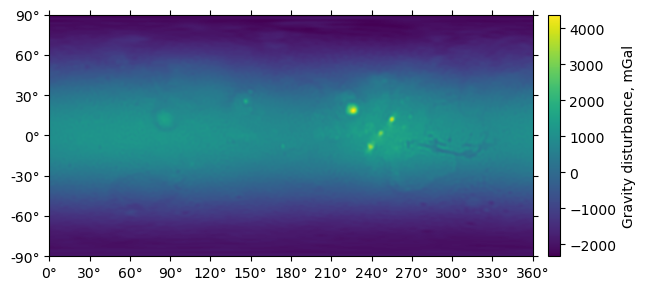

In [2]:
omega = sh.datasets.Mars.MRO120F()
expansion = omega.expand()
expansion.plot_total()

(<Figure size 640x320 with 2 Axes>, <Axes: >)

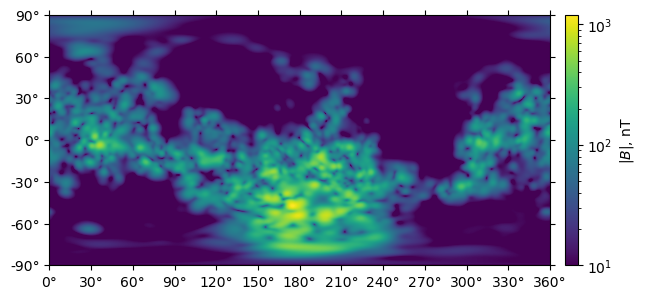

In [ ]:
import pyshtools as sh
d25 = sh.datasets.Mars.PINN2025()
assert isinstance(d25, sh.SHMagCoeffs)
expansion = d25.expand(a = d25.r0 + 150000)
expansion.plot_total(cmap_scale='log',cmap_limits=(10,1200))

Max field (nT): 69628.03142773292
Min field (nT): 0.0


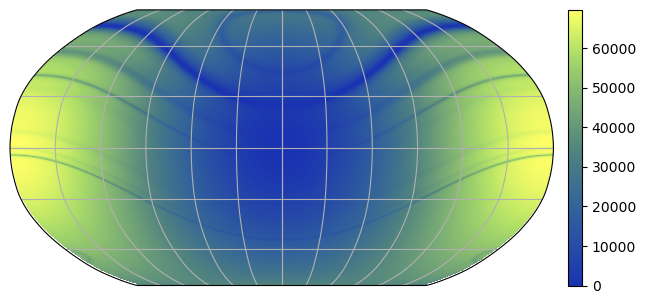

In [2]:

d25 = sh.SHMagCoeffs.from_file('../crustal_field_model/PINN2025.sh')
d25 = d25.change_ref(3393.5e3+150e3)

coeffs_rotation = d25.coeffs.copy()
alphas = list(np.arange(0.1,360,0.1))
n = len(alphas)+1
for alpha in alphas:
    coeffs_rotation += d25.rotate(alpha,0,0).coeffs
coeffs_rotation /= n
coeffs_rotation = sh.SHMagCoeffs.from_array(coeffs_rotation,r0=d25.r0)

# # season = 'summer' # 'summer', 'winter', 'spring', 'autumn' or None
# if season == 'summer':
coeffs_rotation = coeffs_rotation.rotate(0,25,0)
# elif season == 'winter':
#     coeffs_rotation = coeffs_rotation.rotate(0,-25,0)
# elif season == 'autumn':
#     coeffs_rotation = coeffs_rotation.rotate(0,-25,-90, convention='x')
# elif season == 'spring':
#     coeffs_rotation = coeffs_rotation.rotate(0,-25,90, convention='x')
# elif season == None:
#     season = ''
# if season is not None:
#     season = '_'+season

expansion_rotation = coeffs_rotation.expand()
total_field = expansion_rotation.total


latitudes = np.linspace(-90,90,281 )
longitudes = np.linspace(0,360,561)
_, latitudes = np.meshgrid(longitudes,latitudes)
colat_rad = np.deg2rad(90-latitudes)
lon_rad = np.deg2rad(longitudes)

n_max = 7*1e4
n = ((np.sin(colat_rad)*np.cos(lon_rad) * n_max) + n_max)/2

grid_final = total_field.data* n/(total_field.data+1/total_field.data )
print("Max field (nT):", np.max(grid_final))
print("Min field (nT):", np.min(grid_final))
grid_final = sh.SHGrid.from_array(grid_final,grid='DH')
fig, ax = grid_final.plot(projection=ccrs.Robinson(central_longitude=180),
                                # cmap_scale='log', 
                                # cmap=cm.lajolla, 
                                cmap=cm.imola, 
                                cmap_reverse=False,
                                grid=True,
                                # tick_interval=[90,30],
                                cmap_limits=[0,69628],
                                colorbar='right',
)




### compute rotation avg of B crust

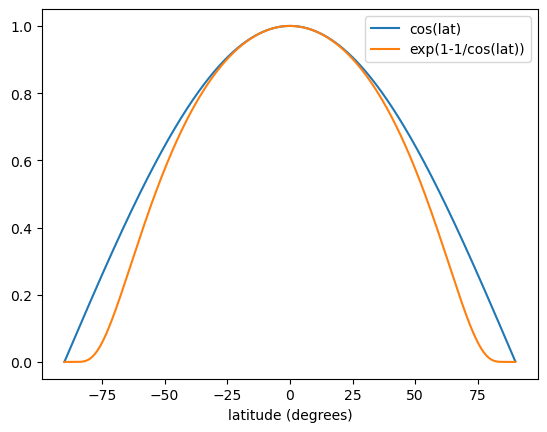

In [3]:
lat = np.arange(-90,90,0.1)
lat = np.deg2rad(lat)
plt.plot(np.rad2deg(lat),np.cos(lat), label='cos(lat)')
# plt.plot(lat,np.sqrt(np.cos(lat)),label='sqrt(cos(lat))')
plt.plot(np.rad2deg(lat), np.exp(1-1/np.cos(lat)), label='exp(1-1/cos(lat))')
plt.xlabel('latitude (degrees)')

plt.legend()


C:\Users\Timothee Delcourt\AppData\Local\Temp\ipykernel_21200\1496583210.py:2: RuntimeWarning: divide by zero encountered in divide
  plt.plot(b, b+1/(b))


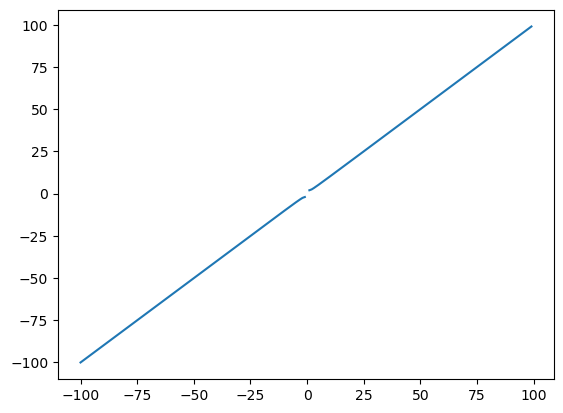

In [4]:
b = np.arange(-100,100,1)
plt.plot(b, b+1/(b))

In [21]:
def plot_rotation_avg(season=None, savefig=False, savecoeffs=False):

    d25 = sh.SHMagCoeffs.from_file('../crustal_field_model/PINN2025.sh')
    d25 = d25.change_ref(3393.5e3+150e3)
    # expansion = d25.expand()
    # # colorbar scale = log
    # expansion.plot_total(projection=ccrs.Robinson(central_longitude=180),
    #                     cmap_scale='log', 
    #                     cmap=cm.lajolla, 
    #                     cmap_reverse=True, 
    #                     cmap_limits=[1e-1,1e3],
    #                     grid=False,
    #                     tick_interval=[60,30],
    #                     xlabel='Longitude (degrees)',
    #                     ylabel='Latitude (degrees)',
    # )

    coeffs_rotation = d25.coeffs.copy()
    alphas = list(np.arange(0.1,360,0.1))
    n = len(alphas)+1
    for alpha in alphas:
        coeffs_rotation += d25.rotate(alpha,0,0).coeffs
    coeffs_rotation /= n
    coeffs_rotation = sh.SHMagCoeffs.from_array(coeffs_rotation,r0=d25.r0)

    # season = 'summer' # 'summer', 'winter', 'spring', 'autumn' or None
    if season == 'summer':
        coeffs_rotation = coeffs_rotation.rotate(0,25,0)
    elif season == 'winter':
        coeffs_rotation = coeffs_rotation.rotate(0,-25,0)
    elif season == 'autumn':
        coeffs_rotation = coeffs_rotation.rotate(0,-25,-90, convention='x')
    elif season == 'spring':
        coeffs_rotation = coeffs_rotation.rotate(0,-25,90, convention='x')
    elif season == None:
        season = ''
    if season is not None:
        season = '_'+season

    if savecoeffs:
        coeffs_rotation.to_file(f'../crustal_field_model/PINN2025_rotation_avg{season}.sh') # bug, winter -> summer

    expansion_rotation = coeffs_rotation.expand()
    total_field = expansion_rotation.total
    # print(f'Max field rotation avg {season} (nT):', np.max(total_field.data))
    # latitudes = np.linspace(-90,90,281 )
    # _, latitudes = np.meshgrid(np.linspace(0,360,561),latitudes)
    # cos_lat = np.cos(np.deg2rad(latitudes))
    # factor = np.exp(1-1/cos_lat)
    # grid_final = total_field.data * factor
    # grid_final = sh.SHGrid.from_array(grid_final,grid='DH')
    # fig, ax = grid_final.plot(projection=ccrs.Robinson(central_longitude=180),
    #                                 cmap_scale='log', 
    #                                 # cmap=cm.lajolla, 
    #                                 cmap=cm.imola, 
    #                                 cmap_reverse=False,
    #                                 # grid=True,
    #                                 # tick_interval=[90,30],
    #                                 cmap_limits=[1e-1,1e2],
    #                                 # colorbar='bottom',
    # )
    # total_field = total_field.
    fig, ax = total_field.plot(projection=ccrs.Robinson(central_longitude=180),
                                    cmap_scale='log', 
                                    # cmap=cm.lajolla, 
                                    cmap=cm.imola, 
                                    cmap_reverse=False,
                                    # grid=True,
                                    # tick_interval=[90,30],
                                    # cmap_limits=[1e-1,1e2],
                                    colorbar='bottom',
    )

    if savefig:
        # fig.savefig(f'../figures/rotation_avg/crustal_field_rotation_avg{season}_chapmanpro.pdf',dpi=300)
        fig.savefig(f'../figures/rotation_avg/crustal_field_rotation_avg{season}.pdf')
        plt.close()
    else:
        plt.show()
    

    

In [27]:
def plot_rotation_avg2(season=None, savefig=False, savecoeffs=False):

    d25 = sh.SHMagCoeffs.from_file('../crustal_field_model/PINN2025.sh')
    d25 = d25.change_ref(3393.5e3 + 150e3)

    alphas = np.arange(0.1, 360, 0.1)
    n = len(alphas) + 1

    # --- longitudinally averaged intensity ---
    expansion = d25.expand()
    total_field_avg = expansion.total.data.copy()

    for alpha in alphas:
        expansion_rot = d25.rotate(alpha, 0, 0).expand()
        total_field_avg += expansion_rot.total.data

    total_field_avg /= n
    print(f'Min after averaging:', np.min(total_field_avg))
    print(f'Max after averaging:', np.max(total_field_avg))

    # --- convert to SH ---
    total_field_avg = sh.SHGrid.from_array(total_field_avg, grid='DH')
    # total_field_avg_sh = sh.expand.SHExpandDH(total_field_avg,norm = 2,
    #                         sampling = 2,
    #                         csphase=1
    #                         )
    total_field_avg_sh = total_field_avg.expand()
    assert isinstance(total_field_avg_sh, sh.SHCoeffs)

    # --- apply seasonal tilt AFTER averaging ---
    if season == 'summer':
        total_field_avg_sh = total_field_avg_sh.rotate(0, 25, 0)
        season = '_summer'
    elif season == 'winter':
        total_field_avg_sh = total_field_avg_sh.rotate(0, -25, 0)
        season = '_winter'
    elif season == 'autumn':
        total_field_avg_sh = total_field_avg_sh.rotate(0, -25, -90, convention='x')
        season = '_autumn'
    elif season == 'spring':
        total_field_avg_sh = total_field_avg_sh.rotate(0, -25, 90, convention='x')
        season = '_spring'
    else:
        season = ''

    if savecoeffs:
        total_field_avg_sh.to_file(f'../crustal_field_model/PINN2025_rotation_avg{season}_real.sh')

    total_field_avg = total_field_avg_sh.expand()
    assert isinstance(total_field_avg, sh.SHGrid)

    # --- plot ---
    fig, ax = total_field_avg.plot(
        projection=ccrs.Robinson(central_longitude=180),
        cmap_scale='log',
        cmap=cm.imola,
        cmap_reverse=False,
        # colorbar='bottom',
    )

    if savefig:
        fig.savefig(f'../figures/rotation_avg/avg_intensity_6.6_to_112_nT/crustal_field_rotation_avg{season}.pdf')
        plt.close()
    else:
        plt.show()


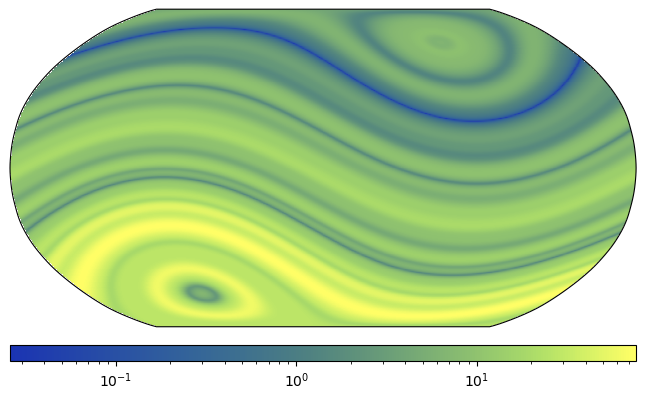

In [ ]:
plot_rotation_avg('spring', savefig=False, savecoeffs=False)

In [29]:
plot_rotation_avg2('spring',savecoeffs=False, savefig=True)

Min after averaging: 6.597865359813768
Max after averaging: 112.09347172136306


In [26]:
# plot_rotation_avg('summer')

for season in [ 'autumn', None, 'summer', 'winter']:
    plot_rotation_avg2(season, savefig=True, savecoeffs=True)

Min after averaging: 6.597865359813768
Max after averaging: 112.09347172136306
Min after averaging: 6.597865359813768
Max after averaging: 112.09347172136306
Min after averaging: 6.597865359813768
Max after averaging: 112.09347172136306
Min after averaging: 6.597865359813768
Max after averaging: 112.09347172136306


### rotation average of unit vector field

In [ ]:
d25 = sh.SHMagCoeffs.from_file('../crustal_field_model/PINN2025.sh')
d25 = d25.change_ref(3393.5e3 + 150e3)

alphas = np.arange(0.1, 360, 0.1)
n = len(alphas) + 1

# --- longitudinally averaged intensity ---
assert isinstance(d25, sh.SHMagCoeffs)
expansion = d25.expand()
total_field_tmp = expansion.total.data.copy()
br_norm_avg = expansion.rad.data.copy()/total_field_tmp
bt_norm_avg = expansion.theta.data.copy()/total_field_tmp
bp_norm_avg = expansion.phi.data.copy()/total_field_tmp

cos_lat = np.cos(np.deg2rad(np.linspace(-90, 90, br_norm_avg.shape[0])))
weights = cos_lat[:, np.newaxis]*np.ones_like(br_norm_avg)

expected_br = np.sum(br_norm_avg * weights)/np.sum(weights)
expected_bt = np.sum(bt_norm_avg * weights)/np.sum(weights)
expected_bp = np.sum(bp_norm_avg * weights)/np.sum(weights)
print("Expected normalized values after longitudinal averaging:")
print("Br norm avg:", expected_br)
print("Bt norm avg:", expected_bt)
print("Bp norm avg:", expected_bp)
var_br = np.sum(weights * (br_norm_avg - expected_br)**2)/np.sum(weights)
var_bt = np.sum(weights * (bt_norm_avg - expected_bt)**2)/np.sum(weights)
var_bp = np.sum(weights * (bp_norm_avg - expected_bp)**2)/np.sum(weights)

print("Variances:")
print("Br norm var:", var_br)
print("Bt norm var:", var_bt)
print("Bp norm var:", var_bp)




var_b = np.array([var_br, var_bt, var_bp])
print("Deviation of variance from 1/3:", var_b - 1/3)



Expected normalized values after longitudinal averaging:
Br norm avg: -0.13426835146517674
Bt norm avg: -0.055640489020351805
Bp norm avg: -0.053701969960327854
Variances:
Br norm var: 0.4075092036336585
Bt norm var: 0.29102674723824046
Bp norm var: 0.27745629332688093
Deviation of variance from 1/3: [ 0.07417587 -0.04230659 -0.05587704]


In [11]:
cos_lat = np.cos(np.deg2rad(np.linspace(-90, 90, br_norm_avg.shape[0])))
weights = cos_lat[:, np.newaxis]*np.ones_like(br_norm_avg)

expected_br = np.sum(br_norm_avg * weights)/np.sum(weights)
expected_bt = np.sum(bt_norm_avg * weights)/np.sum(weights)
expected_bp = np.sum(bp_norm_avg * weights)/np.sum(weights)
print("Expected normalized values after longitudinal averaging:")
print("Br norm avg:", expected_br)
print("Bt norm avg:", expected_bt)
print("Bp norm avg:", expected_bp)
var_br = np.sum(weights * (br_norm_avg - expected_br)**2)/np.sum(weights)
var_bt = np.sum(weights * (bt_norm_avg - expected_bt)**2)/np.sum(weights)
var_bp = np.sum(weights * (bp_norm_avg - expected_bp)**2)/np.sum(weights)

print("Variances:")
print("Br norm var:", var_br)
print("Bt norm var:", var_bt)
print("Bp norm var:", var_bp)
print("The field orientation is thus random and isotropic after longitudinal averaging.")

Expected normalized values after longitudinal averaging:
Br norm avg: -0.1345650668108036
Bt norm avg: -0.05564846899554333
Bp norm avg: -0.053855691054874644
Variances:
Br norm var: 0.024962823486878775
Bt norm var: 0.015527443456141878
Bp norm var: 0.0038212570622411465
The field orientation is thus random and isotropic after longitudinal averaging.


In [30]:
print(np.sum(cos_lat))

178.25166626337213


### playground

(<Figure size 640x576 with 2 Axes>,
 <Axes: xlabel='Spherical harmonic order', ylabel='Spherical harmonic degree'>)

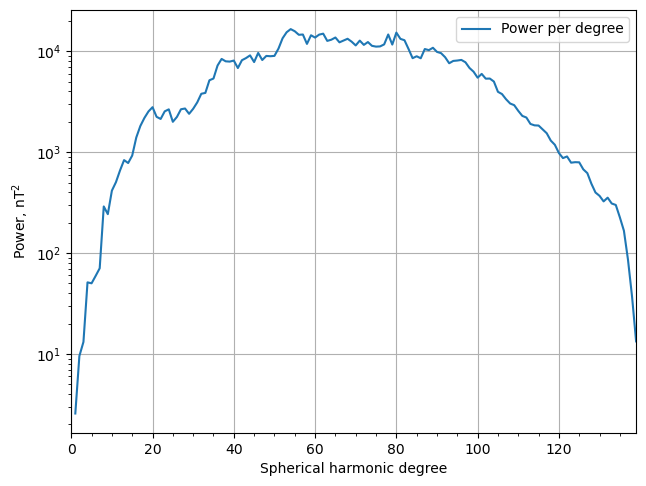

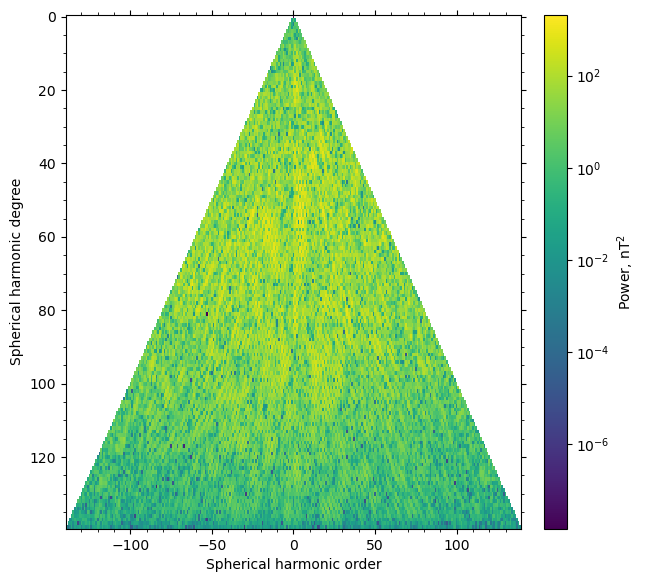

In [4]:
d25 = sh.SHMagCoeffs.from_file('../crustal_field_model/PINN2025.sh')
d25.plot_spectrum()
d25.plot_spectrum2d()

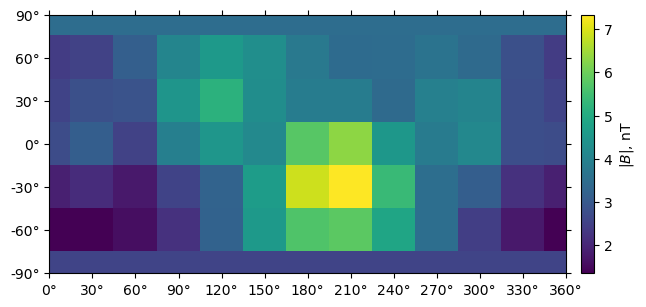

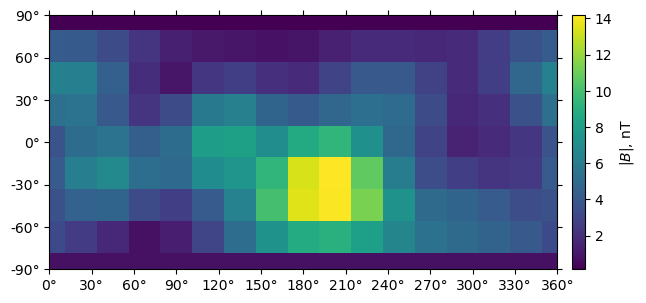

Error in callback <function flush_figures at 0x000001A39FB05940> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [16]:
l_list = list(range(2, 20))
l_list.append(134)
for l in l_list:
    l19 = sh.datasets.Mars.Langlais2019(lmax=l)
    expansion = l19.expand()
    expansion.plot_total()